# Semantic Segmentation of Tomatoes with U-Net

## Table of Contents

1. [Introduction](#1--introduction)
2. [Setup and Imports](#2--setup-and-imports)
3. [Data Loading and Preprocessing](#3--data-loading-and-preprocessing)
4. [Data Augmentation](#4--data-augmentation)
5. [U-Net Model Definition](#5--u-net-model-definition)
6. [Training](#6--training)
7. [Evaluation](#7--evaluation)
8. [Visualization](#8--visualization)

## 1- Introduction
This notebook implements a U-Net model for semantic segmentation of tomato images. Semantic segmentation is the task of classifying each pixel in an image into a specific category or class. The U-Net architecture is particularly effective for biomedical image segmentation tasks.

## 2- Setup and Imports

In [2]:
import os
from glob import glob
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.metrics import MeanIoU


## 3- Data Loading and Preprocessing

In [3]:
from google.colab import drive
import os
import glob
from PIL import Image
import matplotlib.pyplot as plt

drive.mount('/content/drive')

base_dir = '/content/drive/My Drive/studies/Tomato_dataset'

train_images = sorted(glob.glob(os.path.join(base_dir, 'Train', '*.jpg')))
train_masks = sorted(glob.glob(os.path.join(base_dir, 'Mask', '*.jpg')))
test_images = sorted(glob.glob(os.path.join(base_dir, 'Test', '*.jpg')))
test_masks = sorted(glob.glob(os.path.join(base_dir, 'Mask2', '*.jpg')))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
def load_images(image_paths, size=(256, 256), is_mask=False):
    images = []
    for path in image_paths:
        if is_mask:
            # For masks, convert to grayscale (1 channel)
            img = Image.open(path).convert('L')
            img = img.resize(size)
            img = np.array(img)
            # Normalize to 0-1 and reshape to have a channel dimension
            img = (img > 128).astype(np.float32)  # Threshold to create binary mask
            img = np.expand_dims(img, axis=-1)  # Add channel dimension
        else:
            # For regular images, keep RGB
            img = Image.open(path).convert('RGB')
            img = img.resize(size)
            img = np.array(img) / 255.0  # Normalize to 0-1
        images.append(img)
    return np.array(images)

In [5]:
X = load_images(train_images, is_mask=False)
y = load_images(train_masks, is_mask=True)
X_test = load_images(test_images, is_mask=False)
y_test = load_images(test_masks, is_mask=True)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X shape: (81, 256, 256, 3)
y shape: (80, 256, 256, 1)
X_test shape: (20, 256, 256, 3)
y_test shape: (20, 256, 256, 1)


In [6]:
# found an image where it doesnt belong
X = X[:-1]


## 4- Data Augmentation

In [7]:
data_gen_args = dict(rotation_range=20, width_shift_range=0.1, height_shift_range=0.1, shear_range=0.1, zoom_range=0.1, horizontal_flip=True, fill_mode='nearest')
image_datagen = ImageDataGenerator(**data_gen_args)
mask_datagen = ImageDataGenerator(**data_gen_args)
# Fit generators
seed = 42
image_datagen.fit(X, augment=True, seed=seed)
mask_datagen.fit(y, augment=True, seed=seed)
train_generator = zip(image_datagen.flow(X, batch_size=16, seed=seed), mask_datagen.flow(y, batch_size=16, seed=seed))


In [8]:
from sklearn.model_selection import train_test_split

# Split into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

## 5- U-Net Model Definition

In [9]:
def unet(input_size=(256, 256, 3)):
    inputs = layers.Input(input_size)
    # Contracting path (encoder) - with reduced filters
    c1 = layers.Conv2D(32, 3, activation='relu', padding='same')(inputs)  # 64 → 32
    p1 = layers.MaxPooling2D()(c1)

    c2 = layers.Conv2D(64, 3, activation='relu', padding='same')(p1)  # 128 → 64
    p2 = layers.MaxPooling2D()(c2)

    # Bottleneck - with reduced filters
    c3 = layers.Conv2D(128, 3, activation='relu', padding='same')(p2)  # 512 → 128

    # Expanding path (decoder) - with reduced filters
    u1 = layers.Conv2DTranspose(64, 2, strides=2, padding='same')(c3)  # 128 → 64
    u1 = layers.concatenate([u1, c2])
    c4 = layers.Conv2D(64, 3, activation='relu', padding='same')(u1)  # Single Conv2D

    u2 = layers.Conv2DTranspose(32, 2, strides=2, padding='same')(c4)  # 64 → 32
    u2 = layers.concatenate([u2, c1])
    c5 = layers.Conv2D(32, 3, activation='relu', padding='same')(u2)  # Single Conv2D

    # Output layer
    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c5)

    # Create and compile model
    model = models.Model(inputs=[inputs], outputs=[outputs])
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy', MeanIoU(num_classes=2)]
    )
    return model

model = unet()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ conv2d[0][0]      │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose    │ (None, 128, 128,  │     32,832 │ conv2d_2[0][0]    │
│ (Conv2DTranspose)   │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 128, 128,  │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 128)              │            │ conv2d_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │     73,792 │ concatenate[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_transpose_1  │ (None, 256, 256,  │      8,224 │ conv2d_3[0][0]    │
│ (Conv2DTranspose)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_1       │ (None, 256, 256,  │          0 │ conv2d_transpose… │
│ (Concatenate)       │ 64)               │            │ conv2d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 256, 256,  │     18,464 │ concatenate_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 256, 256,  │         33 │ conv2d_4[0][0]    │
│                     │ 1)                │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 226,593 (885.13 KB)

 Trainable params: 226,593 (885.13 KB)

 Non-trainable params: 0 (0.00 B)

## 6- Training

In [10]:
# Define callbacks
callbacks = [
    tf.keras.callbacks.ModelCheckpoint('unet_tomato.h5', save_best_only=True),
    tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True)
]

# Properly pass the training data to fit
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=16,
    callbacks=callbacks
)

Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(16, 256, 256, 3))
  warnings.warn(msg)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.8522 - loss: 0.5928 - mean_io_u: 0.4262 

4/4 ━━━━━━━━━━━━━━━━━━━━ 57s 13s/step - accuracy: 0.8507 - loss: 0.5849 - mean_io_u: 0.4255 - val_accuracy: 0.8636 - val_loss: 0.4236 - val_mean_io_u: 0.4318
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.8374 - loss: 0.4021 - mean_io_u: 0.4187 

4/4 ━━━━━━━━━━━━━━━━━━━━ 78s 13s/step - accuracy: 0.8389 - loss: 0.3965 - mean_io_u: 0.4194 - val_accuracy: 0.8636 - val_loss: 0.3718 - val_mean_io_u: 0.4318
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14s/step - accuracy: 0.8323 - loss: 0.3742 - mean_io_u: 0.4158 

...

4/4 ━━━━━━━━━━━━━━━━━━━━ 52s 14s/step - accuracy: 0.8844 - loss: 0.3073 - mean_io_u: 0.4282 - val_accuracy: 0.8854 - val_loss: 0.3377 - val_mean_io_u: 0.4318
Epoch 10/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.8847 - loss: 0.3092 - mean_io_u: 0.4267 

4/4 ━━━━━━━━━━━━━━━━━━━━ 81s 13s/step - accuracy: 0.8846 - loss: 0.3101 - mean_io_u: 0.4258 - val_accuracy: 0.8856 - val_loss: 0.3369 - val_mean_io_u: 0.4318
Epoch 11/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 83s 13s/step - accuracy: 0.8799 - loss: 0.3245 - mean_io_u: 0.4190 - val_accuracy: 0.8850 - val_loss: 0.3385 - val_mean_io_u: 0.4318
Epoch 12/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 57s 15s/step - accuracy: 0.8899 - loss: 0.3043 - mean_io_u: 0.4212 - val_accuracy: 0.8836 - val_loss: 0.3393 - val_mean_io_u: 0.4318
Epoch 13/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 52s 13s/step - accuracy: 0.8877 - loss: 0.2994 - mean_io_u: 0.4271 - val_accuracy: 0.8831 - val_loss: 0.3387 - val_mean_io_u: 0.4318
Epoch 14/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 81s 13s/step - accuracy: 0.8864 - loss: 0.3050 - mean_io_u: 0.4237 - val_accuracy: 0.8832 - val_loss: 0.3381 - val_mean_io_u: 0.4318
Epoch 15/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.8831 - loss: 0.3052 - mean_io_u: 0.4240 

4/4 ━━━━━━━━━━━━━━━━━━━━ 52s 13s/step - accuracy: 0.8835 - loss: 0.3056 - mean_io_u: 0.4237 - val_accuracy: 0.8836 - val_loss: 0.3369 - val_mean_io_u: 0.4318
Epoch 16/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 82s 13s/step - accuracy: 0.8805 - loss: 0.3221 - mean_io_u: 0.4185 - val_accuracy: 0.8853 - val_loss: 0.3434 - val_mean_io_u: 0.4318
Epoch 17/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11s/step - accuracy: 0.8867 - loss: 0.3042 - mean_io_u: 0.4207 

4/4 ━━━━━━━━━━━━━━━━━━━━ 50s 13s/step - accuracy: 0.8863 - loss: 0.3047 - mean_io_u: 0.4210 - val_accuracy: 0.8839 - val_loss: 0.3363 - val_mean_io_u: 0.4318
Epoch 18/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 81s 12s/step - accuracy: 0.8872 - loss: 0.3017 - mean_io_u: 0.4248 - val_accuracy: 0.8845 - val_loss: 0.3365 - val_mean_io_u: 0.4318
Epoch 19/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12s/step - accuracy: 0.8888 - loss: 0.2935 - mean_io_u: 0.4235 

4/4 ━━━━━━━━━━━━━━━━━━━━ 85s 13s/step - accuracy: 0.8880 - loss: 0.2957 - mean_io_u: 0.4233 - val_accuracy: 0.8832 - val_loss: 0.3362 - val_mean_io_u: 0.4318
Epoch 20/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 82s 13s/step - accuracy: 0.8817 - loss: 0.3112 - mean_io_u: 0.4204 - val_accuracy: 0.8842 - val_loss: 0.3385 - val_mean_io_u: 0.4318


## 7- Evaluation

In [11]:
results = model.evaluate(X_test, y_test)
print(dict(zip(model.metrics_names, results)))


/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(None, 256, 256, 3))
  warnings.warn(msg)


1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.9678 - loss: 0.1575 - mean_io_u: 0.4270
{'loss': 0.157455712556839, 'compile_metrics': 0.9677734375}


## 8- Visualization

/usr/local/lib/python3.11/dist-packages/keras/src/models/functional.py:237: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['keras_tensor']
Received: inputs=Tensor(shape=(1, 256, 256, 3))
  warnings.warn(msg)


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 565ms/step


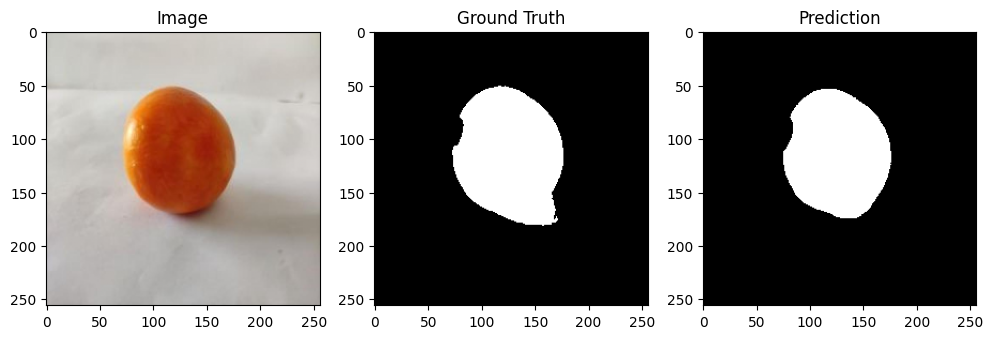

In [12]:
# Predict and plot sample
idx = 0  # change index for different samples
pred = model.predict(X_test[idx:idx+1])[0,:,:,0] > 0.5
plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.title('Image'); plt.imshow(X_test[idx])
plt.subplot(1,3,2); plt.title('Ground Truth'); plt.imshow(y_test[idx,:,:,0], cmap='gray')
plt.subplot(1,3,3); plt.title('Prediction'); plt.imshow(pred, cmap='gray')
plt.show()
